# MNIST transfer purification — MPS vs JEM

This notebook produces and displays transfer-attack grids for MPS and JEM. The first two grids use likelihood/score purification; the next two use MPS Gibbs and JEM SGLD at $k=10$ sweeps. The final grid purifies exactly the same MPS transfer examples with both model families.

Run from the project root with the `bm4tc` environment. Gibbs at $k=10$ is deliberately expensive.

In [1]:
import sys
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display

# This notebook lives in notebooks/; Jupyter's CWD is that folder. Walk up to the
# repo root (the dir containing src/) so all analysis/figures paths resolve.
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT = {PROJECT_ROOT}")


from analysis.visualize.mnist_transfer_purify import (
    MODELS as MPS_MODELS,
    _load_model as load_mps_model,
    _test_loader as mps_test_loader,
)
from baselines.jem.analysis import _load as load_jem_run
from baselines.jem.attacks import PGDConfig, pgd_classification
from baselines.jem.device import resolve_device
from baselines.jem.purification import (
    PurificationConfig as JEMPurificationConfig,
    gradient_purify,
    sgld_purify_snapshots,
)
from baselines.jem.transfer_purify import MODELS as JEM_MODELS
from src.analysis.purification import GibbsPurification, LikelihoodPurification
from src.utils.evasion import ProjectedGradientDescent

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "outputs").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "outputs").is_dir():
    raise FileNotFoundError(f"Could not locate the project root from {Path.cwd()}")
os.chdir(PROJECT_ROOT)  # The model paths below are relative to the project root.
DEVICE = resolve_device("cuda:0" if torch.cuda.is_available() else "cpu")
CLASSES = [0, 3, 5, 9]
EPS_REL = 0.2
LIKELIHOOD_RADIUS_REL = 0.3
LOCAL_RADIUS_REL = 0.2
ATTACK_STEPS = 40
LIKELIHOOD_STEPS = 20
K = 10
MAX_ATTACK_SAMPLES = 2000
BATCH_SIZE = 128

MPS_OUT = PROJECT_ROOT / "figures/mnist_r12/transfer_purify"
JEM_OUT = PROJECT_ROOT / "figures/jem_mnist/transfer_purify"
MPS_OUT.mkdir(parents=True, exist_ok=True)
JEM_OUT.mkdir(parents=True, exist_ok=True)
torch.manual_seed(0); np.random.seed(0)
print(f"device: {DEVICE}")

PROJECT_ROOT = /Users/jose/VSCodeProjects/bm4tc


INFO:baselines.jem.device:Using cpu


device: cpu


In [2]:
# Load every concrete checkpoint once and print the exact setup.
mps = {}
for key, label, path in MPS_MODELS:
    model, cfg, run_dir = load_mps_model(path, DEVICE)
    mps[key] = dict(label=label, model=model, cfg=cfg, run_dir=run_dir)

jem = {}
for key, label, path in JEM_MODELS:
    run_dir = Path(path)
    cfg, model, datahandler, sampler = load_jem_run(run_dir, DEVICE)
    model.eval()
    jem[key] = dict(label=label, model=model, cfg=cfg, run_dir=run_dir, datahandler=datahandler, sampler=sampler)

mps_lo, mps_hi = map(float, mps["at"]["model"].input_range)
jem_lo, jem_hi = map(float, jem["at"]["model"].input_range)
assert (mps_lo, mps_hi) == (jem_lo, jem_hi), "The shared comparison requires the same input range."
abs_attack = EPS_REL * (mps_hi - mps_lo)
print("MPS models")
for key, entry in mps.items():
    born = entry["cfg"].born
    print(f"  {key:4s} | run={entry['run_dir']} | {born.embedding} | d={born.init_kwargs.in_dim}, bond={born.init_kwargs.bond_dim}")
print("JEM models")
for key, entry in jem.items():
    print(f"  {key:4s} | run={entry['run_dir']} | JEMMLP | parameters={entry['model'].count_parameters():,}")
print("Purification / attack configuration")
print(f"  attack: PGD L∞, eps={EPS_REL} relative = {abs_attack:.3f} absolute, {ATTACK_STEPS} steps")
print(f"  MPS likelihood: L∞ radius={LIKELIHOOD_RADIUS_REL} relative = {LIKELIHOOD_RADIUS_REL * (mps_hi-mps_lo):.3f}, {LIKELIHOOD_STEPS} steps")
print(f"  MPS Gibbs: k={K} sweeps, local per-sweep radius={LOCAL_RADIUS_REL} relative = {LOCAL_RADIUS_REL * (mps_hi-mps_lo):.3f}")
print(f"  JEM score ascent: L∞ radius={LIKELIHOOD_RADIUS_REL} relative = {LIKELIHOOD_RADIUS_REL * (jem_hi-jem_lo):.3f}, {LIKELIHOOD_STEPS} steps")
print(f"  JEM SGLD: k={K} sweeps × {JEMPurificationConfig().num_steps} transitions, local radius={LOCAL_RADIUS_REL} relative = {LOCAL_RADIUS_REL * (jem_hi-jem_lo):.3f}")

INFO:analysis.utils.mia_utils:Reconstructed config for outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a0_2406/0 from /Users/jose/VSCodeProjects/bm4tc/configs/experiments/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a0.yaml
INFO:src.model:[CBM] Cached log Z = 58.579002
INFO:analysis.visualize.mnist_transfer_purify:Loaded outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a0_2406/0
INFO:analysis.utils.mia_utils:Reconstructed config for outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a001_2007/0 from /Users/jose/VSCodeProjects/bm4tc/configs/experiments/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a001.yaml
INFO:src.model:[CBM] Cached log Z = 106.815903
INFO:analysis.visualize.mnist_transfer_purify:Loaded outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a001_2007/0
INFO:analysis.utils.mia_utils:Reconstructed config for outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a01_2107/0 from /Users/jose/VSCodeProjects/bm4tc/configs/experiments/mnist_full_r1

MPS models
  a0   | run=outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a0_2406/0 | legendre | d=3, bond=20
  a001 | run=outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a001_2007/0 | legendre | d=3, bond=20
  a01  | run=outputs/mnist_full_r12/nat/legendre/d3r20c64/seed_sweep/a01_2107/0 | legendre | d=3, bond=20
  at   | run=outputs/mnist_full_r12/at/legendre/d3r20c64/seed_sweep/a0_2507/0 | legendre | d=3, bond=20
JEM models
  a0   | run=outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a0_2607/0 | JEMMLP | parameters=349,040
  a001 | run=outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a001_2607/0 | JEMMLP | parameters=349,040
  a01  | run=outputs/baselines/jem/mnist_full_r12/nat/mlp_h550x480/seed_sweep/a01_2607/0 | JEMMLP | parameters=349,040
  at   | run=outputs/baselines/jem/mnist_full_r12/at/mlp_h550x480/seed_sweep/at_2707/0 | JEMMLP | parameters=349,040
Purification / attack configuration
  attack: PGD L∞, eps=0.2 relative = 0.400 abs

In [3]:
def predict_mps(model, x):
    with torch.no_grad():
        return model.class_probabilities(x).argmax(1).cpu().numpy()

def predict_jem(model, x):
    with torch.no_grad():
        return model(x).argmax(1).cpu().numpy()

def collect_transfer(entries, source_key, loader, predict, attack):
    """Keep examples every displayed model gets right clean and wrong after attack."""
    keys = list(entries)
    clean_parts, adv_parts, label_parts = [], [], []
    attacked = 0
    for clean, labels in loader:
        if attacked >= MAX_ATTACK_SAMPLES:
            break
        remaining = MAX_ATTACK_SAMPLES - attacked
        clean, labels = clean[:remaining].to(DEVICE), labels[:remaining].to(DEVICE)
        attacked += len(clean)
        clean_pred = {key: predict(entries[key]['model'], clean) for key in keys}
        adversarial = attack(entries[source_key]['model'], clean, labels)
        adv_pred = {key: predict(entries[key]['model'], adversarial) for key in keys}
        y = labels.cpu().numpy()
        mask = np.ones(len(y), dtype=bool)
        for key in keys:
            mask &= clean_pred[key] == y
            mask &= adv_pred[key] != y
        if mask.any():
            idx = np.flatnonzero(mask)
            clean_parts.append(clean[idx].cpu())
            adv_parts.append(adversarial[idx].cpu())
            label_parts.append(y[idx])
    if not label_parts:
        raise RuntimeError('No fully transferring examples found; increase MAX_ATTACK_SAMPLES or EPS_REL.')
    return dict(clean=torch.cat(clean_parts), adv=torch.cat(adv_parts), labels=np.concatenate(label_parts), attacked=attacked)

def selected_rows(examples):
    rows = []
    for class_idx in CLASSES:
        hits = np.flatnonzero(examples['labels'] == class_idx)
        rows.append(int(hits[0]) if len(hits) else None)
    return rows

def selected_tensor(examples, rows, key='adv'):
    indices = [index for index in rows if index is not None]
    return examples[key][torch.as_tensor(indices)], indices

def restore_rows(values, rows):
    restored, position = [], 0
    for index in rows:
        restored.append(None if index is None else values[position])
        position += index is not None
    return restored

def display_grid(title, rows, columns, output):
    figure, axes = plt.subplots(len(CLASSES), len(columns), figsize=(1.65 * len(columns), 1.8 * len(CLASSES)), squeeze=False)
    for row, class_idx in enumerate(CLASSES):
        for column, (label, images) in enumerate(columns.items()):
            axis = axes[row, column]
            axis.set_xticks([]); axis.set_yticks([])
            image = images[row]
            if image is None:
                axis.set_facecolor('0.9')
                if column == 0: axis.text(.5, .5, 'n/a', ha='center', va='center', transform=axis.transAxes)
            else:
                axis.imshow(((image.float() - mps_lo) / (mps_hi - mps_lo)).reshape(12, 12), cmap='gray', vmin=0, vmax=1)
        axes[row, 0].set_ylabel(f'$y={class_idx}$')
    for column, label in enumerate(columns): axes[0, column].set_title(label, fontsize=10)
    figure.suptitle(title, y=1.02)
    figure.tight_layout()
    figure.savefig(output, dpi=300, bbox_inches='tight')
    display(figure)
    plt.close(figure)

def mps_likelihood(model, data):
    return LikelihoodPurification(norm='inf', num_steps=LIKELIHOOD_STEPS).purify(model, data, LIKELIHOOD_RADIUS_REL * (mps_hi-mps_lo), DEVICE)[0].cpu()

def mps_gibbs(model, data):
    return GibbsPurification(num_bins=20, gibbs_batch_size=8, step_radius=LOCAL_RADIUS_REL).purify(model, data, K, DEVICE)[0].cpu()

def jem_score(model, data):
    return gradient_purify(model, data.to(DEVICE), JEMPurificationConfig(radius=LIKELIHOOD_RADIUS_REL * (jem_hi-jem_lo), num_steps=LIKELIHOOD_STEPS)).cpu()

def jem_sgld(entry, data):
    cfg = JEMPurificationConfig(radius=LOCAL_RADIUS_REL * (jem_hi-jem_lo), num_steps=20, step_size=0.01, sgld_noise_std=0.005)
    return sgld_purify_snapshots(entry['model'], entry['sampler'], data.to(DEVICE), cfg, (K,))[K].cpu()

INFO:src.datahandler:MNIST loaded: 70000 samples, 144 features
INFO:src.datahandler:Generated dataset 'mnist_full' and saved to /Users/jose/VSCodeProjects/bm4tc/.datasets/mnist/mnist_full_r12.npz


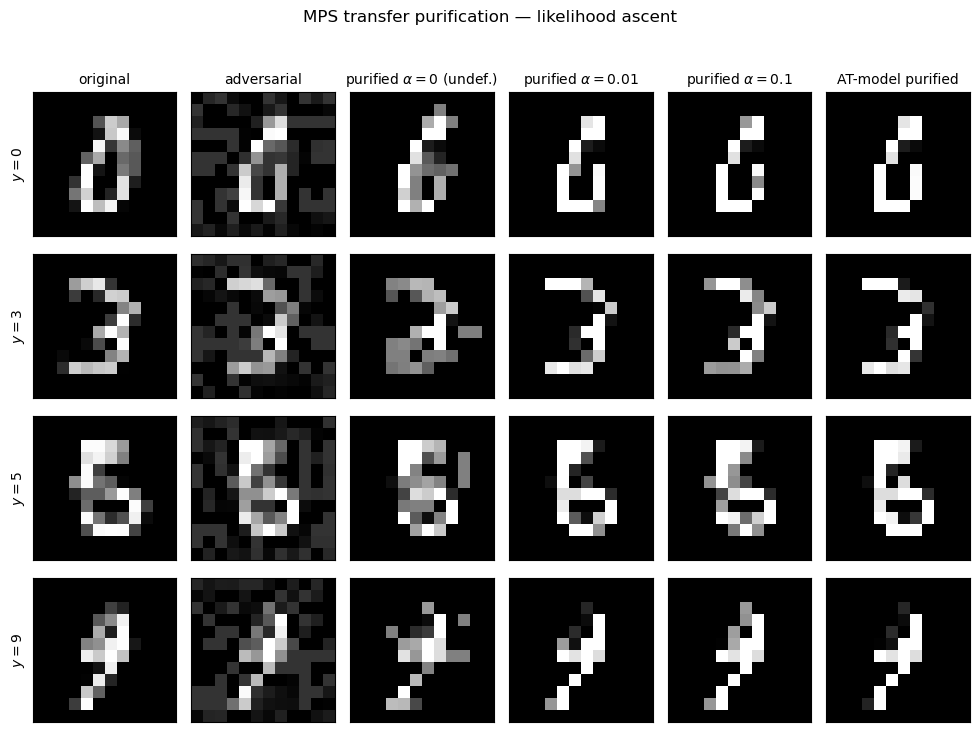

Gibbs:   0%|          | 0/1 [00:00<?, ?batch/s]

sweep 1/10:   0%|          | 0/144 [00:00<?, ?feat/s]

sweep 2/10:   0%|          | 0/144 [00:00<?, ?feat/s]

sweep 3/10:   0%|          | 0/144 [00:00<?, ?feat/s]

sweep 4/10:   0%|          | 0/144 [00:00<?, ?feat/s]

...

sweep 7/10:   0%|          | 0/144 [00:00<?, ?feat/s]

sweep 8/10:   0%|          | 0/144 [00:00<?, ?feat/s]

sweep 9/10:   0%|          | 0/144 [00:00<?, ?feat/s]

sweep 10/10:   0%|          | 0/144 [00:00<?, ?feat/s]

Gibbs log p(x):   0%|          | 0/1 [00:00<?, ?batch/s]

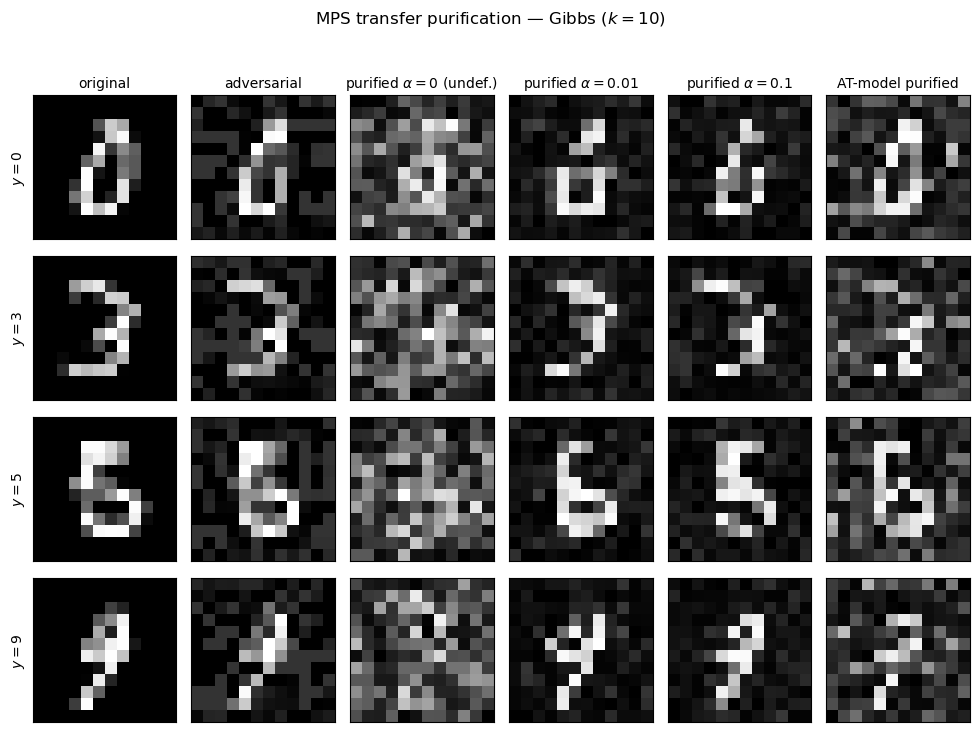

In [4]:
# MPS transfer grid: likelihood purification and Gibbs purification at k=10.
mps_loader = mps_test_loader(mps['at']['cfg'], mps['at']['model'], BATCH_SIZE)
mps_examples = collect_transfer(
    mps, 'at', mps_loader, predict_mps,
    lambda model, x, y: ProjectedGradientDescent(norm='inf', num_steps=ATTACK_STEPS, random_start=True).generate(model, x, y, abs_attack, DEVICE),
)
mps_rows = selected_rows(mps_examples)
mps_adv, _ = selected_tensor(mps_examples, mps_rows)
mps_clean_rows = [None if i is None else mps_examples['clean'][i] for i in mps_rows]
mps_adv_rows = [None if i is None else mps_examples['adv'][i] for i in mps_rows]
mps_like = {key: restore_rows(mps_likelihood(entry['model'], mps_adv), mps_rows) for key, entry in mps.items()}
display_grid(
    'MPS transfer purification — likelihood ascent', mps_rows,
    {'original': mps_clean_rows, 'adversarial': mps_adv_rows, **{entry['label']: mps_like[key] for key, entry in mps.items()}},
    MPS_OUT / 'transfer_purify_likelihood_grid.pdf',
)
mps_gibbs_rows = {key: restore_rows(mps_gibbs(entry['model'], mps_adv), mps_rows) for key, entry in mps.items()}
display_grid(
    f'MPS transfer purification — Gibbs ($k={K}$)', mps_rows,
    {'original': mps_clean_rows, 'adversarial': mps_adv_rows, **{entry['label']: mps_gibbs_rows[key] for key, entry in mps.items()}},
    MPS_OUT / f'transfer_purify_gibbs_k{K}_grid.pdf',
)

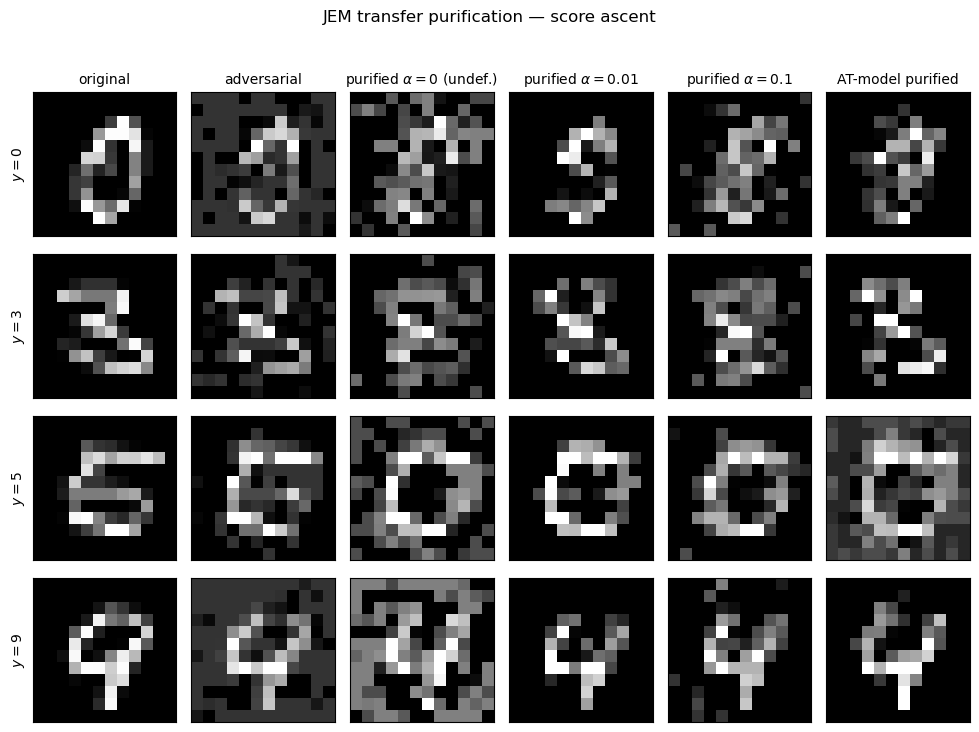

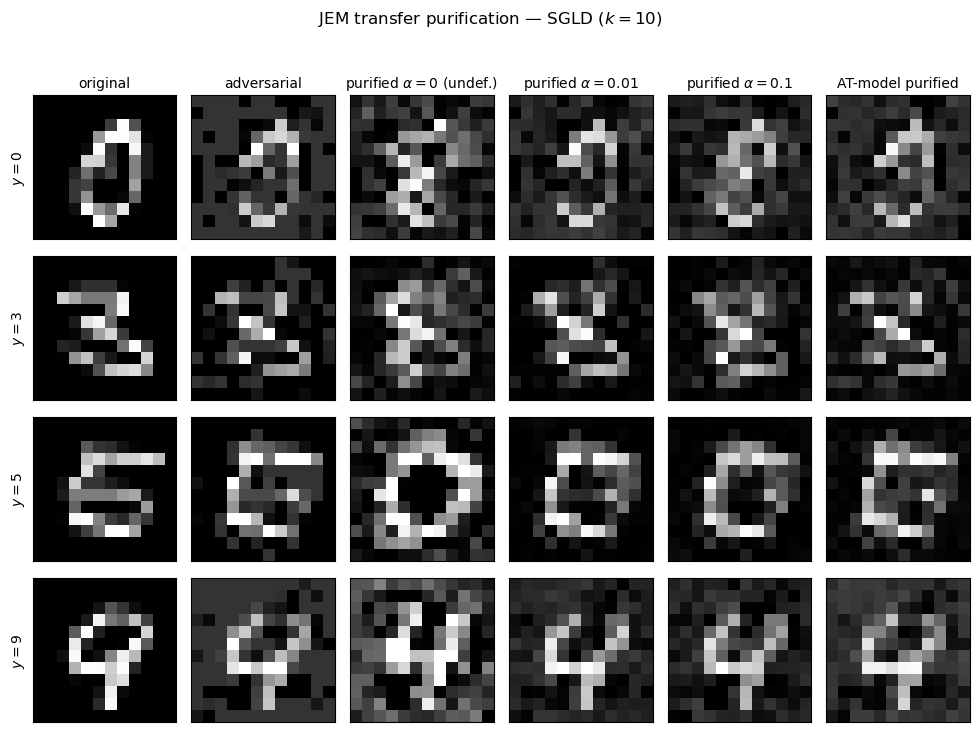

In [7]:
# JEM transfer grid: score purification and SGLD purification at k=10.
jem_loader = jem['at']['datahandler'].classification['test']
jem_examples = collect_transfer(
    jem, 'at', jem_loader, predict_jem,
    lambda model, x, y: pgd_classification(model, x, y, PGDConfig(epsilon=abs_attack, num_steps=ATTACK_STEPS)),
)
jem_rows = selected_rows(jem_examples)
jem_adv, _ = selected_tensor(jem_examples, jem_rows)
jem_clean_rows = [None if i is None else jem_examples['clean'][i] for i in jem_rows]
jem_adv_rows = [None if i is None else jem_examples['adv'][i] for i in jem_rows]
jem_score_rows = {key: restore_rows(jem_score(entry['model'], jem_adv), jem_rows) for key, entry in jem.items()}
display_grid(
    'JEM transfer purification — score ascent', jem_rows,
    {'original': jem_clean_rows, 'adversarial': jem_adv_rows, **{entry['label']: jem_score_rows[key] for key, entry in jem.items()}},
    JEM_OUT / 'transfer_purify_score_grid.pdf',
)
jem_sgld_rows = {key: restore_rows(jem_sgld(entry, jem_adv), jem_rows) for key, entry in jem.items()}
display_grid(
    f'JEM transfer purification — SGLD ($k={K}$)', jem_rows,
    {'original': jem_clean_rows, 'adversarial': jem_adv_rows, **{entry['label']: jem_sgld_rows[key] for key, entry in jem.items()}},
    JEM_OUT / f'transfer_purify_sgld_k{K}_grid.pdf',
)

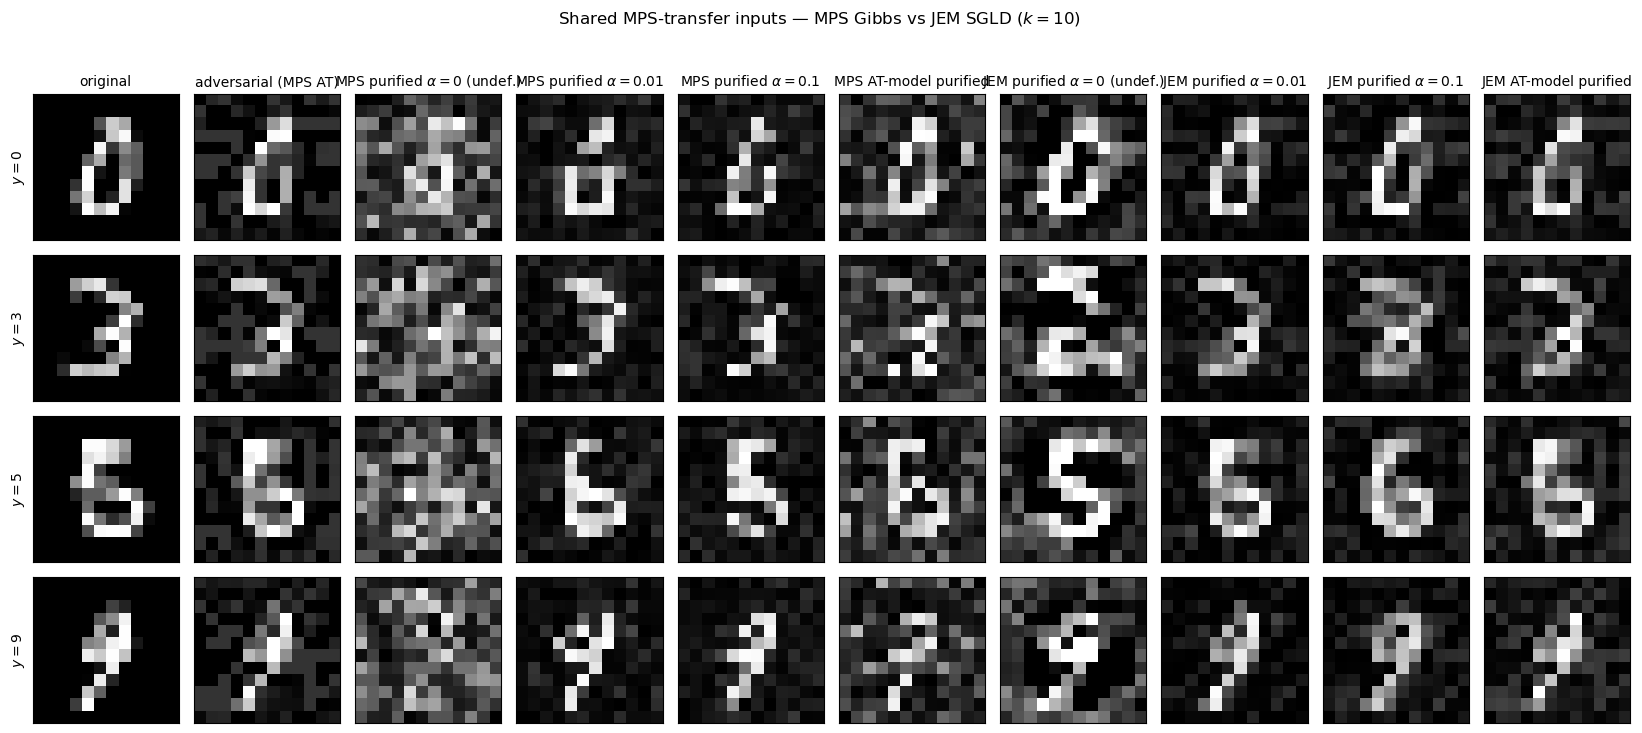

In [6]:
# Same MPS-transfer inputs, purified side-by-side by every MPS and JEM model.
# The original and adversarial columns below are therefore bit-identical for both families.
shared_jem_sgld = {key: restore_rows(jem_sgld(entry, mps_adv), mps_rows) for key, entry in jem.items()}
display_grid(
    f'Shared MPS-transfer inputs — MPS Gibbs vs JEM SGLD ($k={K}$)', mps_rows,
    {
        'original': mps_clean_rows,
        'adversarial (MPS AT)': mps_adv_rows,
        **{f'MPS {entry["label"]}': mps_gibbs_rows[key] for key, entry in mps.items()},
        **{f'JEM {entry["label"]}': shared_jem_sgld[key] for key, entry in jem.items()},
    },
    JEM_OUT / f'transfer_purify_mps_jem_shared_k{K}_grid.pdf',
)

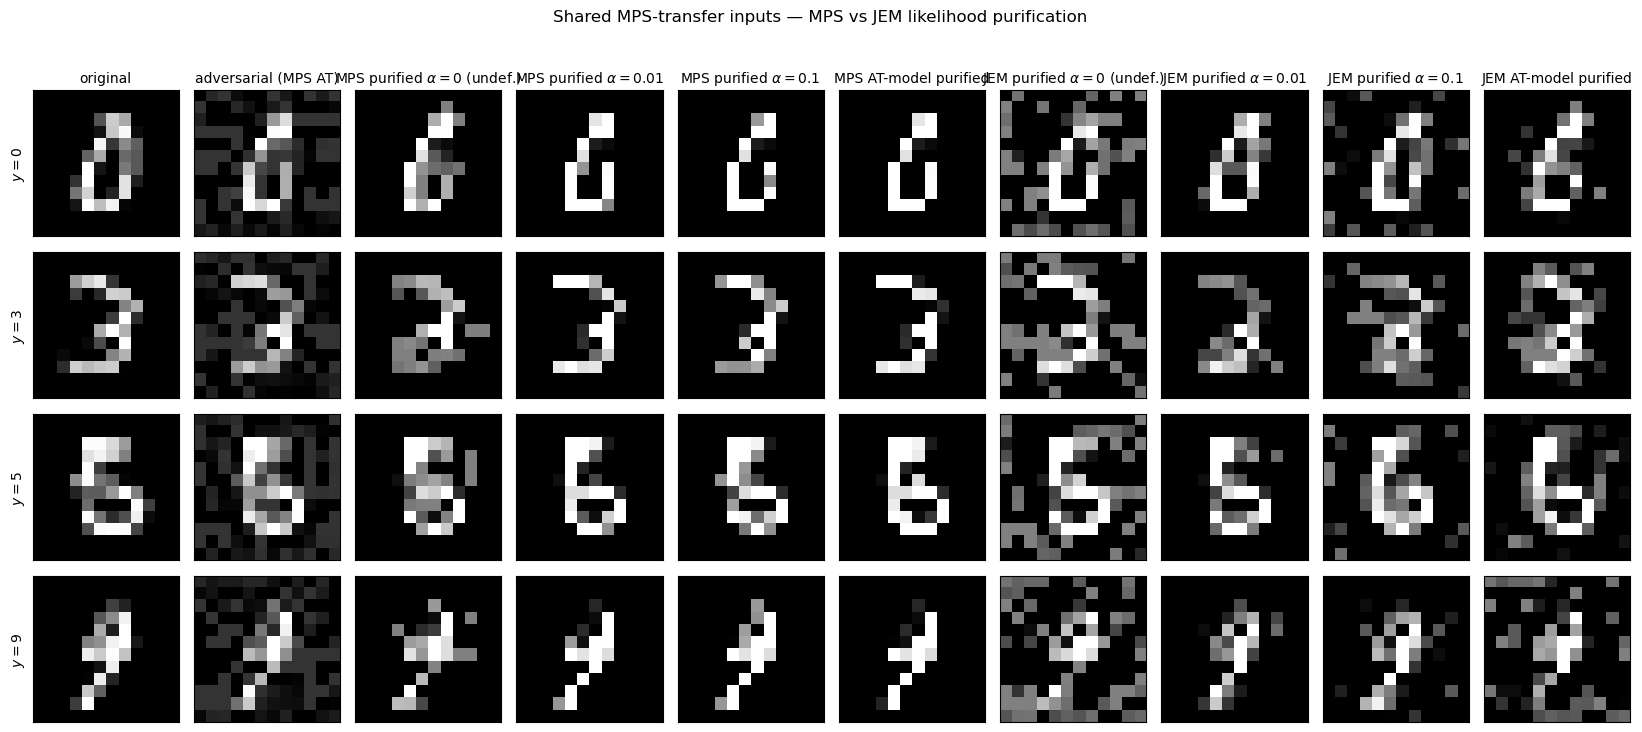

In [8]:
# Same MPS-transfer inputs, now compared with likelihood/score purification in both families.
# MPS uses marginal-likelihood ascent; JEM uses ascent of its marginal score.
shared_jem_score = {key: restore_rows(jem_score(entry['model'], mps_adv), mps_rows) for key, entry in jem.items()}
display_grid(
    'Shared MPS-transfer inputs — MPS vs JEM likelihood purification', mps_rows,
    {
        'original': mps_clean_rows,
        'adversarial (MPS AT)': mps_adv_rows,
        **{f'MPS {entry["label"]}': mps_like[key] for key, entry in mps.items()},
        **{f'JEM {entry["label"]}': shared_jem_score[key] for key, entry in jem.items()},
    },
    JEM_OUT / 'transfer_purify_mps_jem_shared_likelihood_grid.pdf',
)